In [1]:
import sys

print(sys.executable)

c:\Users\HP\rag-complaint-chatbot\.venv\Scripts\python.exe


In [1]:
import sys

print(sys.executable)

c:\Users\HP\rag-complaint-chatbot\.venv\Scripts\python.exe


# Task 1: Exploratory Data Analysis and Preprocessing

## Intelligent Complaint Analysis for Financial Services

Goal:
Analyze CFPB complaint data and prepare clean data for the RAG pipeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/raw/complaints.csv")

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_12172\3032069356.py:1: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/complaints.csv")


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [4]:
df.shape

(9609797, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 6.7 GB


In [6]:
df.columns.tolist()

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Consumer consent provided?',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Consumer disputed?',
 'Complaint ID']

In [7]:
df["Consumer complaint narrative"].isna().sum()

np.int64(6629041)

In [8]:
df["Consumer complaint narrative"].notna().sum()

np.int64(2980756)

In [9]:
df["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

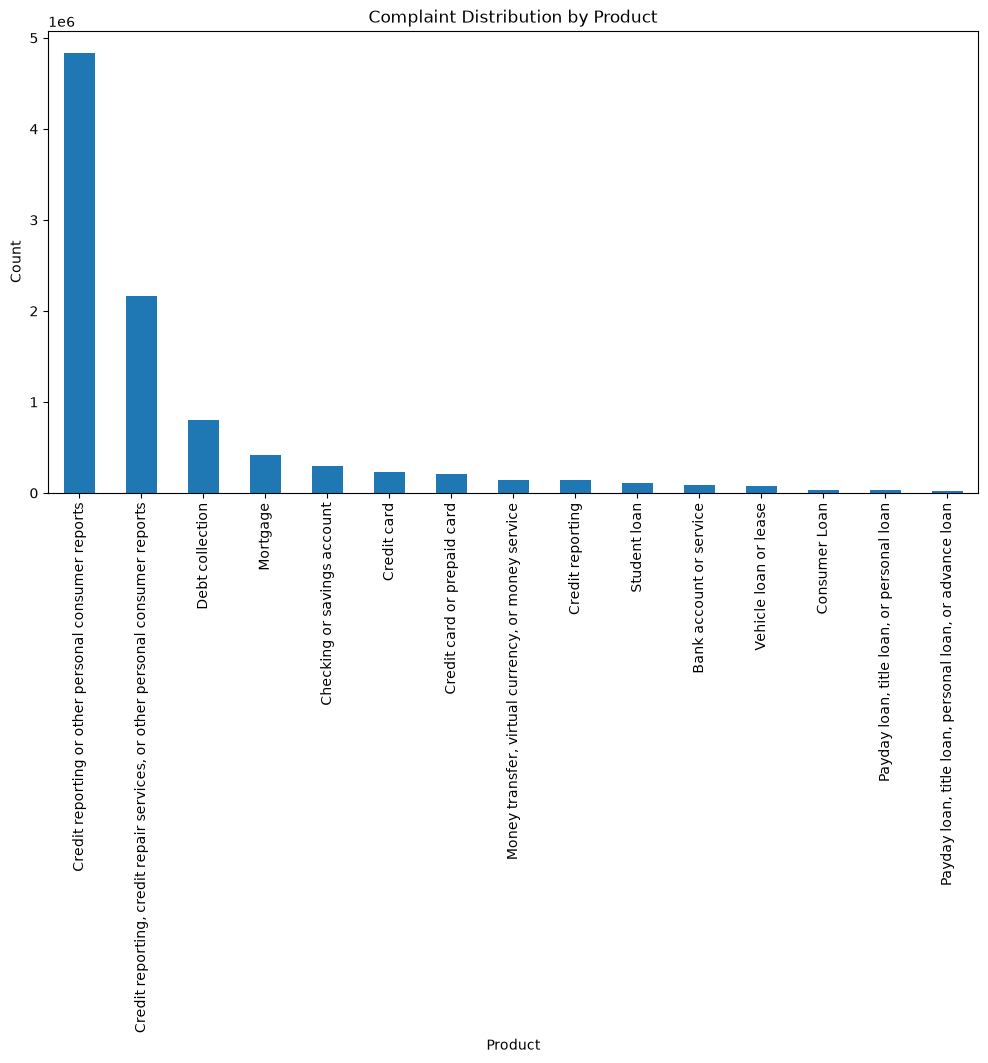

In [10]:
plt.figure(figsize=(12,6))

df["Product"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Complaint Distribution by Product")
plt.ylabel("Count")
plt.show()

In [11]:
sorted(df["Product"].unique())

['Bank account or service',
 'Checking or savings account',
 'Consumer Loan',
 'Credit card',
 'Credit card or prepaid card',
 'Credit reporting',
 'Credit reporting or other personal consumer reports',
 'Credit reporting, credit repair services, or other personal consumer reports',
 'Debt collection',
 'Debt or credit management',
 'Money transfer, virtual currency, or money service',
 'Money transfers',
 'Mortgage',
 'Other financial service',
 'Payday loan',
 'Payday loan, title loan, or personal loan',
 'Payday loan, title loan, personal loan, or advance loan',
 'Prepaid card',
 'Student loan',
 'Vehicle loan or lease',
 'Virtual currency']

In [12]:
target_products = [
    "Credit card",
    "Credit card or prepaid card",
    "Checking or savings account",
    "Money transfer, virtual currency, or money service",
    "Money transfers",
    "Consumer Loan",
    "Payday loan, title loan, or personal loan",
    "Payday loan, title loan, personal loan, or advance loan"
]

filtered_df = df[
    (df["Product"].isin(target_products))
    &
    (df["Consumer complaint narrative"].notna())
].copy()

In [13]:
filtered_df.shape

(463933, 18)

In [14]:
filtered_df["Product"].value_counts()

Product
Checking or savings account                                140319
Credit card or prepaid card                                108667
Money transfer, virtual currency, or money service          97188
Credit card                                                 80667
Payday loan, title loan, or personal loan                   17238
Consumer Loan                                                9461
Payday loan, title loan, personal loan, or advance loan      8896
Money transfers                                              1497
Name: count, dtype: int64

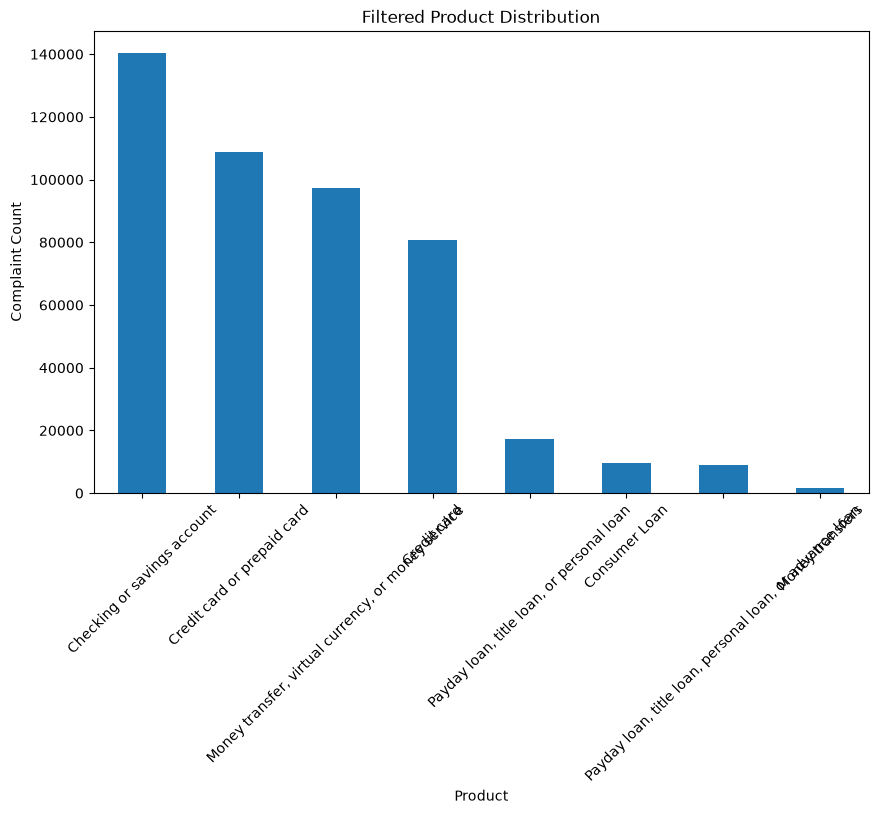

In [15]:
plt.figure(figsize=(10,6))

filtered_df["Product"].value_counts().plot(
    kind="bar"
)

plt.title("Filtered Product Distribution")
plt.ylabel("Complaint Count")
plt.xticks(rotation=45)
plt.show()

In [16]:
filtered_df["narrative_length"] = (
    filtered_df["Consumer complaint narrative"]
    .str.split()
    .str.len()
)

In [17]:
filtered_df["narrative_length"].describe()

count    463933.000000
mean        205.036303
std         227.137225
min           1.000000
25%          82.000000
50%         136.000000
75%         254.000000
max        6469.000000
Name: narrative_length, dtype: float64

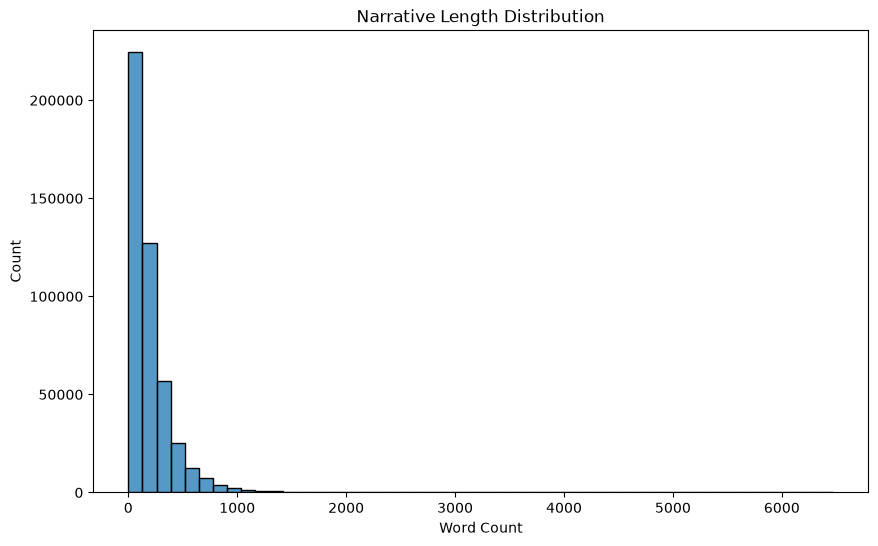

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    filtered_df["narrative_length"],
    bins=50
)

plt.title("Narrative Length Distribution")
plt.xlabel("Word Count")
plt.show()

In [19]:
filtered_df[
    filtered_df["narrative_length"] < 10
][["Consumer complaint narrative"]].head()

,Consumer complaint narrative
148427,I received a text message regarding a non-exis...
496919,Negligence to provide permissible reporting on...
587641,"Fraudulent activity, improper access, blocked ..."
641355,Zelle fine print misleading with no customer r...
644211,Zelle allowed fraudulent transfers and provide...


In [20]:
threshold = filtered_df["narrative_length"].quantile(0.99)

filtered_df[
    filtered_df["narrative_length"] > threshold
][["Consumer complaint narrative"]].head()

,Consumer complaint narrative
66156,"To Whom It May Concern at Wells Fargo, I am wr..."
78844,I was contacted by a pop up on my laptop in XX...
115259,XXXXOn or about XXXX XXXX XXXX I received a ch...
142278,b'I chat with automatic system chat service XX...
158329,-- -- -- -- -- Forwarded message -- -- -- -- -...


In [21]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    boilerplates = [
        "i am writing to file a complaint",
        "this complaint is regarding"
    ]

    for phrase in boilerplates:
        text = text.replace(phrase, "")

    return text.strip()

In [22]:
filtered_df["clean_narrative"] = (
    filtered_df["Consumer complaint narrative"]
    .apply(clean_text)
)

In [23]:
filtered_df[
    [
        "Consumer complaint narrative",
        "clean_narrative"
    ]
].head()

,Consumer complaint narrative,clean_narrative
12237,A XXXX XXXX card was opened under my name by a...,a xxxx xxxx card was opened under my name by a...
12532,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
13280,"Dear CFPB, I have a secured credit card with c...",dear cfpb i have a secured credit card with ci...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13955,b'I am writing to dispute the following charge...,b i am writing to dispute the following charge...


In [24]:
filtered_df.to_csv(
    "../data/processed/filtered_complaints.csv",
    index=False
)

In [25]:
filtered_df.shape

(463933, 20)

In [29]:
import re
import pandas as pd

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # remove leading b'
    text = re.sub(r"^b['\"]", "", text)

    text = text.lower()

    boilerplates = [
        "i am writing to file a complaint",
        "this complaint is regarding"
    ]

    for phrase in boilerplates:
        text = text.replace(phrase, "")

    text = re.sub(r"[^a-z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [30]:
filtered_df["clean_narrative"] = (
    filtered_df["Consumer complaint narrative"]
    .apply(clean_text)
)

In [31]:
filtered_df.to_csv(
    "../data/processed/filtered_complaints.csv",
    index=False
)

In [32]:
product_mapping = {

    "Credit card": "Credit Card",

    "Credit card or prepaid card": "Credit Card",

    "Checking or savings account": "Savings Account",

    "Money transfer, virtual currency, or money service":
        "Money Transfer",

    "Money transfers":
        "Money Transfer",

    "Consumer Loan":
        "Personal Loan",

    "Payday loan, title loan, or personal loan":
        "Personal Loan",

    "Payday loan, title loan, personal loan, or advance loan":
        "Personal Loan"
}

In [33]:
filtered_df["product_category"] = (
    filtered_df["Product"]
    .map(product_mapping)
)

In [34]:
filtered_df["product_category"].value_counts()

product_category
Credit Card        189334
Savings Account    140319
Money Transfer      98685
Personal Loan       35595
Name: count, dtype: int64

In [35]:
sample_df = (
    filtered_df
    .groupby(
        "product_category",
        group_keys=False
    )
    .apply(
        lambda x:
        x.sample(
            frac=0.03,
            random_state=42
        )
    )
)

In [36]:
sample_df.shape

(13919, 20)

In [37]:
sample_df.to_csv(
    "../data/processed/sample_complaints.csv",
    index=False
)